#  Calculation of features from available libraries

In [1]:
import sys
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')

import os
import pandas as pd

dataset = 'Cr-Co-W'
system=dataset.replace('-','')
from BopFoxFeaturizer.Featurizer import Featurizer

import Tools.DatasetTools.GeneralFeaturizer as gf

BS = pd.read_pickle(os.path.join(dataset, 'FullyCuratedParsedBriefSummary.pkl'))
AtomsObjects = pd.read_pickle(os.path.join(dataset, 'Atomsobjects', f'{system}-POSCAR-initial-rescaled-AtomsObjects.pkl')).dropna()
PymatgenStructures = pd.read_pickle(os.path.join(dataset, 'Atomsobjects', f'{system}-POSCAR-initial-rescaled-PymatgenStructures.pkl')).dropna()
SublatticeTags = pd.read_pickle(os.path.join(dataset,'Atomsobjects', 'SUBLATICETAGS.pkl'))
SublatticeSorters = pd.read_pickle(os.path.join(dataset,'Atomsobjects', 'SORTERS.pkl'))
SublatticeSorters.index = SublatticeSorters.index.str.strip()
SublatticeTags.index = SublatticeSorters.index.str.strip()

BS.dropna(inplace=True)

import numpy as np

In [2]:
BS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_C,num_atom_A,num_atom_B,num_atom_C,num_atoms,Co_pv,Cr_pv,W_sv,EF,Phase
index,,,,,,,,,,,,,,,,,,,,,
Co_pv6W_sv6.C14-BBA.FM,bulk C14-BBA.FM,13.175678 A,-10.000427,293.907391 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,2,...,,6,6,0,12.0,0.500000,0.000000,0.500000,-0.008728,C14
Co_pv6W_sv6.C14-BBA.NM,bulk C14-BBA,13.175679 A,-10.000427,293.949578 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,2,...,,6,6,0,12.0,0.500000,0.000000,0.500000,-0.008728,C14
Cr_pv6W_sv2.D0_19-A3B.FM,bulk D0_19-A3B.FM,13.098145 A,-10.002413,244.993002 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,2,...,,6,2,0,8.0,0.000000,0.750000,0.250000,0.36766,hcp
Cr_pv6W_sv2.D0_19-A3B.NM,bulk D0_19-A3B,13.093819 A,-10.002452,248.338396 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,2,...,,6,2,0,8.0,0.000000,0.750000,0.250000,0.367621,hcp
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,bulk sigma-CBAAC.FM,13.525828 A,-10.003732,243.415325 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,3,...,W_sv,16,4,10,30.0,0.133333,0.533333,0.333333,0.322855,sigma
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,bulk sigma-BAACA,13.189913 A,-9.988760,251.071094 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,3,...,W_sv,20,2,8,30.0,0.066667,0.666667,0.266667,0.27345,sigma
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,bulk sigma-BAACA.FM,13.189987 A,-9.988760,251.093896 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,3,...,W_sv,20,2,8,30.0,0.066667,0.666667,0.266667,0.27345,sigma
Co_pv13W_sv16.chi-ABAB.NM,bulk chi-ABAB,14.051746 A,-9.988843,263.749012 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,2,...,,13,16,0,29.0,0.448276,0.000000,0.551724,0.309268,chi


# Prepare Extra features

In [3]:
from sklearn.preprocessing import  OneHotEncoder, LabelEncoder
encoder = LabelEncoder()

In [4]:
Features = Featurizer(BS)

In [5]:
DatasetCompositionFeatures = Features.get_fractions_by_components()

In [6]:
#DatasetFeatures = pd.concat((DatasetCompositionFeatures, DatasetMagneticFeature, StructureNameFeature), axis=1)

##  Magnetism and structure

In [7]:
StructureNameFeature = BS.Phase
StructureNameFeature.name='Structure'
encoder.fit(StructureNameFeature)
DatasetStructureFeature = pd.Series(encoder.transform(StructureNameFeature), name='Structure', index = StructureNameFeature.index)

In [8]:
MagneticFeature = Features.Mag
MagneticFeature.name = 'Mag'
encoder.fit(MagneticFeature)
DatasetMagneticFeature = pd.Series(encoder.transform(MagneticFeature), name='Mag', index = StructureNameFeature.index)

In [9]:
DatasetFeatures = pd.concat([DatasetMagneticFeature, DatasetStructureFeature, DatasetCompositionFeatures, BS.num_atoms], axis = 1)

## Coordination Polyhedra feature

The first feature that we would like to have is the count of each CP in each sample. for that we construct a vector in the following way:

$$ N_{CN}^i = \#^i CN $$

Next feature we want is the composition in each CP. for this we choose to represent the elment numerically by their atomic numbers, and the CP-resolved composition becomes the average atomc numbers,

$$ Z_{CP} ^i = \dfrac{1}{n_{at}^i} \sum_{at \in CP} Z_{at} $$

In [10]:
SortingFeatures = gf.sorting_feature(AtomsObjects, SublatticeSorters, SublatticeTags)

In [11]:
SortingFeatures.sorters = gf.correct_sortings_fromphases(AtomsObjects, BS.Phase, SortingFeatures.sorters)

In [12]:
SortingFeatures.sublatticetags = gf.correct_occupation_fromphases(BS.Phase, SortingFeatures.sublatticetags, AtomsObjects.atoms)

In [13]:
sampleinspecial = BS.Phase.map(lambda p: p in gf.specialphases)

In [14]:
empty = SortingFeatures.sublatticetags.map(lambda sublat: '' in sublat)

In [15]:
SortingFeatures.sublatticetags[empty] = ['A']

In [16]:
wrong = SortingFeatures.sublatticetags.map(lambda sublat: 'A' not in sublat) 

In [17]:
gf.correct_occupation_fromphases(BS.Phase[wrong], SortingFeatures.sublatticetags[wrong], AtomsObjects.atoms[wrong])

Co_pv2W_sv4.C15-AB2.NM                                    [C, C, C, C, M, M]
Co_pv2W_sv4.C15-AB2.FM                                    [C, C, C, C, M, M]
Cr_pv4W_sv2.C15-A2B.FM                                    [C, C, C, C, M, M]
Cr_pv4W_sv2.C15-A2B.NM                                    [C, C, C, C, M, M]
Cr_pv2W_sv4.C15-AB2.NM                                    [C, C, C, C, M, M]
Cr_pv2W_sv4.C15-AB2.FM                                    [C, C, C, C, M, M]
Cr_pv1W_sv1.B2-AB.NM                                                  [C, C]
Cr_pv1W_sv1.B2-AB.FM                                                  [C, C]
W_sv1.fcc.FM               Cr-Co-W/data/W_sv/POSCAR-initial/fcc-cubic.FM/...
W_sv4.fcc-cubic.FM         Cr-Co-W/data/W_sv/POSCAR-initial/fcc-cubic.FM/...
W_sv12.C14.NM                           [M, M, M, M, Z, Z, Z, Z, Z, Z, Z, Z]
W_sv6.C15.NM                                              [C, C, C, C, M, M]
Co_pv6.C15.NM                                             [C, C, C, C, M, M]

In [18]:
fixable = SortingFeatures.sublatticetags.loc[wrong].map(type) == np.ndarray #.map(np.unique)

In [19]:
SortingFeatures.sublatticetags[fixable.index]#.map(np.unique)

Co_pv2W_sv4.C15-AB2.NM                                    [C, C, C, C, M, M]
Co_pv2W_sv4.C15-AB2.FM                                    [C, C, C, C, M, M]
Cr_pv4W_sv2.C15-A2B.FM                                    [C, C, C, C, M, M]
Cr_pv4W_sv2.C15-A2B.NM                                    [C, C, C, C, M, M]
Cr_pv2W_sv4.C15-AB2.NM                                    [C, C, C, C, M, M]
Cr_pv2W_sv4.C15-AB2.FM                                    [C, C, C, C, M, M]
Cr_pv1W_sv1.B2-AB.NM                                                  [C, C]
Cr_pv1W_sv1.B2-AB.FM                                                  [C, C]
W_sv1.fcc.FM               Cr-Co-W/data/W_sv/POSCAR-initial/fcc-cubic.FM/...
W_sv4.fcc-cubic.FM         Cr-Co-W/data/W_sv/POSCAR-initial/fcc-cubic.FM/...
W_sv12.C14.NM                           [M, M, M, M, Z, Z, Z, Z, Z, Z, Z, Z]
W_sv6.C15.NM                                              [C, C, C, C, M, M]
Co_pv6.C15.NM                                             [C, C, C, C, M, M]

In [21]:
#uniquewrong = SortingFeatures.sublatticetags[wrong].map(np.unique)

In [22]:
CNList = gf.get_sitecn(BS.Phase, AtomsObjects.atoms, SortingFeatures.sorters)

  0%|          | 0/1716 [00:00<?, ?it/s]

In [23]:
CNList

Co_pv6W_sv6.C14-BBA.FM                 [12, 12, 12, 12, 12, 12, 16, 16, 16, 16, 12, 12]
Co_pv6W_sv6.C14-BBA.NM                 [12, 12, 12, 12, 12, 12, 16, 16, 16, 16, 12, 12]
Cr_pv6W_sv2.D0_19-A3B.FM                               [12, 12, 12, 12, 12, 12, 12, 12]
Cr_pv6W_sv2.D0_19-A3B.NM                               [12, 12, 12, 12, 12, 12, 12, 12]
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM    [12, 12, 15, 15, 15, 15, 14, 14, 14, 14, 14, 1...
                                                            ...                        
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM     [12, 12, 15, 15, 15, 15, 14, 14, 14, 14, 14, 1...
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM     [12, 12, 15, 15, 15, 15, 14, 14, 14, 14, 14, 1...
Co_pv13W_sv16.chi-ABAB.NM             [16, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 1...
Co_pv13W_sv16.chi-ABAB.FM             [16, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 1...
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.NM    [12, 12, 15, 15, 15, 15, 14, 14, 14, 14, 14, 1...
Length: 1716, dtype: object

## Position Features

In [24]:
elements = np.unique(BS.filter(regex='^atom_').values.ravel())

In [25]:
ABOCC = pd.concat([BS.filter(regex='atom_'), Features.occupation], axis = 1)

In [26]:
ABOCC.rename(columns={ABOCC.columns[-1]: 'index'}, inplace=True)

In [27]:
Positions = {}
for index, item in ABOCC.iterrows():
    if item['index'] == '':
        thisposition = {index: [item[f'atom_A']]*len(np.unique(gf.cn_dict[BS.Phase[index]]))}
    else:
        thisposition = {index: [item[f'atom_{occ}'] for occ in item['index'] ]}
    Positions.update(thisposition)
Positions = pd.DataFrame.from_dict(Positions, orient='index')
Positions[Positions.isnull()] = 0
for i, element in enumerate(elements):
    Positions[Positions==element] = i
Positions.columns = [f'Pos_{col+1}' for col in Positions.columns]
#Positions[Positions.Pos_1.map(type) == str] = np.nan

## Averages over Coordination polyhedra

### Number of each CP in each structure

In [28]:
CN = gf.featurize_series(CNList, CNList, normalization='NCP', return0 = False)
newcolumns = ['N'+col for col in CN.columns]
CN.columns = newcolumns

### Composition and volume of the CP

In [29]:
from mendeleev import element

In [30]:
AtomicNumbers=AtomsObjects.atoms.map(lambda a: a.numbers)
AtomicNumbers.name = 'AtomicNumbers'
symbols = dataset.split('-')
volums = {symb: element(symb).atomic_volume for symb in symbols}

In [31]:
AtomicVolumes = AtomsObjects.atoms.map(lambda a: [volums[at] for at in a.get_chemical_symbols()])

In [32]:
CPVol = gf.featurize_series(AtomicVolumes, CNList, return0=False, normalization='NCP')
newcolumns = ['V'+col for col in CPVol.columns]
CPVol.columns =  newcolumns

In [33]:
CPComp = gf.featurize_series(AtomicNumbers, CNList, return0=False, normalization='NCP')
newcolumns = ['Z'+col for col in CPComp.columns]
CPComp.columns = newcolumns

## Compile all the descriptors

In [34]:
DatasetFeatures = pd.concat([DatasetStructureFeature, DatasetMagneticFeature, DatasetCompositionFeatures, CN, CPVol, CPComp, BS.num_atoms, Positions], axis=1)

In [35]:
datasetfeatureslocation = os.path.join(dataset, 'Descriptors','DatasetFeatures.pkl')

In [36]:
CNListlocation = os.path.join(dataset, 'Descriptors', 'CNList.pkl')

In [37]:
DatasetFeatures.to_pickle(datasetfeatureslocation)

In [38]:
CNList.to_pickle(CNListlocation)

# Matminer Features 

In [39]:
from Tools.DatasetTools.GetPymatgenFeatures import *

In [40]:
descriptorslocation = os.path.join(dataset, 'Descriptors')
mmflatomic = os.path.join(descriptorslocation, 'matminer_atomic_features.pkl')
mmfdensity = os.path.join (descriptorslocation, 'matminer_density_features.pkl')
mmfcomposition =  os.path.join (descriptorslocation,'matminer_composition_features.pkl')
mmfstructure =  os.path.join (descriptorslocation,'matminer_structure_features.pkl')
mmsoapfeatures = os.path.join(descriptorslocation, 'matminer_soap_features.pkl')


BS['chemical_formula'] = get_chemical_formula(BS)

In [41]:
BS['composition'] = StrToComposition().featurize_dataframe(BS, "chemical_formula")['composition']

StrToComposition:   0%|          | 0/1716 [00:00<?, ?it/s]

In [42]:
BS['atoms_objects'] = PymatgenStructures

In [43]:
AtomicFeaturesMagpie = load_features(mmflatomic, BS, which='atomic')
DensitiFeatures= load_features(mmfdensity, BS, which='density')
CompositionFeatures = load_features(mmfcomposition, BS, which='composition')
# SOAPFeatures = load_features(mmfstructure, BS, which='soap')
# SOAP doesnt work from matminer
# StructureFeatures = load_features(mmfstructure, BS, which='structure')

In [44]:
AtomicFeaturesMagpie.columns = AtomicFeaturesMagpie.columns.str.replace('MagpieData ','')
AtomicFeaturesMagpie.dropna(axis=1, inplace = True)
AtomicFeaturesMagpie.describe()

,minimum Number,maximum Number,range Number,mean Number,avg_dev Number,mode Number,minimum MendeleevNumber,maximum MendeleevNumber,range MendeleevNumber,mean MendeleevNumber,...,range GSmagmom,mean GSmagmom,avg_dev GSmagmom,mode GSmagmom,minimum SpaceGroupNumber,maximum SpaceGroupNumber,range SpaceGroupNumber,mean SpaceGroupNumber,avg_dev SpaceGroupNumber,mode SpaceGroupNumber
count,1716.000000,1716.000000,1716.000000,1716.000000,1716.000000,1716.000000,1716.000000,1716.000000,1716.000000,1716.000000,...,1716.000000,1716.000000,1716.000000,1716.000000,1716.000000,1716.000000,1716.000000,1716.000000,1716.000000,1716.000000
mean,24.884033,67.403846,42.519814,46.787105,13.388904,47.229604,49.342075,56.899767,7.557692,52.797551,...,1.298514,0.503265,0.422338,0.471038,199.425408,228.775641,29.350233,217.624737,9.546082,217.047786
std,4.878101,16.364670,16.785047,15.831210,8.441321,24.014179,0.985671,2.575140,2.666637,2.123384,...,0.569879,0.446254,0.275702,0.712607,12.670745,2.794061,12.880942,10.086647,6.231675,16.602190
min,24.000000,24.000000,0.000000,24.000000,0.000000,24.000000,49.000000,49.000000,0.000000,49.000000,...,0.000000,0.000000,0.000000,0.000000,194.000000,194.000000,0.000000,194.000000,0.000000,194.000000
25%,24.000000,74.000000,47.000000,33.307692,5.856753,27.000000,49.000000,58.000000,7.000000,51.137255,...,1.548471,0.122248,0.181461,0.000000,194.000000,229.000000,35.000000,211.500000,4.101562,194.000000
50%,24.000000,74.000000,50.000000,44.704244,13.583829,27.000000,49.000000,58.000000,9.000000,52.166667,...,1.548471,0.387118,0.430131,0.000000,194.000000,229.000000,35.000000,220.250000,9.722222,229.000000
75%,24.000000,74.000000,50.000000,62.461538,21.555556,74.000000,49.000000,58.000000,9.000000,53.923077,...,1.548471,0.774236,0.688209,1.548471,194.000000,229.000000,35.000000,226.236842,15.555556,229.000000
max,74.000000,74.000000,50.000000,74.000000,24.793388,74.000000,58.000000,58.000000,9.000000,58.000000,...,1.548471,1.548471,0.774236,1.548471,229.000000,229.000000,35.000000,229.000000,17.500000,229.000000


In [45]:
DensitiFeatures.dropna(axis=1, inplace=True)
if DensitiFeatures.shape[1] > 0:
    DensitiFeatures.describe()

In [46]:
CompositionFeatures.dropna(axis=1, inplace=True)
CompositionFeatures.describe()

,HOMO_energy,LUMO_energy,gap_AO,band center,max ionic char,avg ionic char,0-norm,2-norm,3-norm,5-norm,7-norm,10-norm
count,1716.000000,1716.000000,1716.000000,1716.000000,1716.000000,1716.000000,1716.000000,1716.000000,1716.000000,1716.000000,1716.000000,1716.000000
mean,-0.208566,-0.207536,0.001029,4.187196,0.091726,0.012599,2.556527,0.755115,0.713276,0.693169,0.687999,0.685381
std,0.050137,0.051001,0.005981,0.145746,0.039563,0.008039,0.541845,0.137422,0.168608,0.186710,0.192094,0.195038
min,-0.322368,-0.322368,0.000000,3.716833,0.000000,0.000000,1.000000,0.584998,0.493242,0.435713,0.416972,0.406636
25%,-0.220603,-0.220603,0.000000,4.080115,0.055973,0.004929,2.000000,0.628932,0.563224,0.530175,0.509580,0.500861
50%,-0.220603,-0.220603,0.000000,4.199398,0.115294,0.013634,3.000000,0.707107,0.673540,0.651528,0.646555,0.645325
75%,-0.181413,-0.181413,0.000000,4.302270,0.115294,0.019309,3.000000,0.897130,0.890964,0.890416,0.890411,0.890411
max,-0.118123,-0.118123,0.054052,4.397803,0.115294,0.028585,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Pyscal features 

In [47]:
atomsobjectlocation = os.path.join(dataset, 'Atomsobjects')
atomsobjectfile = os.path.join(atomsobjectlocation,f'{system}-POSCAR-initial-rescaled-AtomsObjects.pkl')

In [48]:
from tqdm.auto import tqdm
from Tools.DatasetTools import pyscalfeaturizers as pf
from BopFoxFeaturizer.struct_db import struct_db
AtomsObjects = pd.read_pickle(atomsobjectfile).dropna()

##  Coordination Numbers

In [49]:
featurizers = [pf.pyscal_steinhardt, pf.pyscal_cn] #, get_steinhardt]
pyscal_features = [feature.__name__ for feature in featurizers]

pyscalsteinhardt = os.path.join(descriptorslocation, 'pyscal_steinhardt.kpl')

if os.path.exists(pyscalsteinhardt):
    PyscalFeatures = pd.read_pickle(pyscalsteinhardt)
else:
    PyscalFeatures = pf.featurize_many(AtomsObjects,  featurizers, colid='atoms')
    expanded_ste = pf.expand_features(PyscalFeatures.pyscal_steinhardt, 'pyscal_steinhardt')
    PyscalFeatures = pd.concat([expanded_ste, PyscalFeatures.pyscal_cn], axis=1)
    PyscalFeatures.to_pickle(pyscalsteinhardt)

In [50]:
PyscalFeatures

,pyscal_steinhardt_0,pyscal_steinhardt_1,pyscal_cn
Co_pv6W_sv6.C14-BBA.FM,"[0.03017068309981547, 0.0301706830998153, 0.03...","[0.6522197642669683, 0.6522197642669681, 0.652...","[12, 12, 12, 12, 12, 12, 16, 16, 16, 16, 12, 12]"
Co_pv6W_sv6.C14-BBA.NM,"[0.03017068309981547, 0.0301706830998153, 0.03...","[0.6522197642669683, 0.6522197642669681, 0.652...","[12, 12, 12, 12, 12, 12, 16, 16, 16, 16, 12, 12]"
Cr_pv6W_sv2.D0_19-A3B.FM,"[0.09323416294012996, 0.09323417179770714, 0.0...","[0.4832106512245095, 0.4832106384449315, 0.483...","[12, 12, 12, 12, 12, 12, 12, 12]"
Cr_pv6W_sv2.D0_19-A3B.NM,"[0.09323416294012996, 0.09323417179770714, 0.0...","[0.4832106512245095, 0.4832106384449315, 0.483...","[12, 12, 12, 12, 12, 12, 12, 12]"
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,"[0.0523612106188882, 0.05236121061888817, 0.05...","[0.4036624849492422, 0.4036624849492422, 0.403...","[14, 14, 14, 14, 14, 14, 14, 14, 12, 12, 12, 1..."
...,...,...,...
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,"[0.023139325263541427, 0.02313932526354089, 0....","[0.31584518048303, 0.31584518048303006, 0.3158...","[15, 15, 15, 15, 14, 14, 14, 14, 14, 14, 14, 1..."
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,"[0.023139325263541427, 0.02313932526354089, 0....","[0.31584518048303, 0.31584518048303006, 0.3158...","[15, 15, 15, 15, 14, 14, 14, 14, 14, 14, 14, 1..."
Co_pv13W_sv16.chi-ABAB.NM,"[0.03160847926125847, 0.0727226549761183, 0.07...","[0.19382539926827577, 0.4519096786468691, 0.45...","[16, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 1..."
Co_pv13W_sv16.chi-ABAB.FM,"[0.03160847926125847, 0.0727226549761183, 0.07...","[0.19382539926827577, 0.4519096786468691, 0.45...","[16, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 1..."


## Stainhardt parameters 

From the Steinhardt parameters obtained by Pyscal library, we also want to average over the coordination polyhedra. This time we are also saving the total average for each parameter.

$$ q_{j, CP} ^i = \dfrac{1}{n_{at}^i}\sum _{at \in CP} q_{j, at} ^i $$

In [51]:
thisFeatures = PyscalFeatures[['pyscal_steinhardt_0','pyscal_steinhardt_1']]

In [52]:
CNPyscal  = gf.featurize_many(thisFeatures, CNList[thisFeatures.index], [gf.cn_average])

  0%|          | 0/1 [00:00<?, ?it/s]

In [53]:
CNPyscal

,pyscal_steinhardt_0_0,pyscal_steinhardt_0_CN12,pyscal_steinhardt_0_CN13,pyscal_steinhardt_0_CN14,pyscal_steinhardt_0_CN15,pyscal_steinhardt_0_CN16,pyscal_steinhardt_1_0,pyscal_steinhardt_1_CN12,pyscal_steinhardt_1_CN13,pyscal_steinhardt_1_CN14,pyscal_steinhardt_1_CN15,pyscal_steinhardt_1_CN16
Co_pv6W_sv6.C14-BBA.FM,0.021754,0.020735,0.000000,0.000000,0.000000,0.001019,0.500586,0.436126,0.000000,0.000000,0.000000,0.064460
Co_pv6W_sv6.C14-BBA.NM,0.021754,0.020735,0.000000,0.000000,0.000000,0.001019,0.500586,0.436126,0.000000,0.000000,0.000000,0.064460
Cr_pv6W_sv2.D0_19-A3B.FM,0.089643,0.089643,0.000000,0.000000,0.000000,0.000000,0.482020,0.482020,0.000000,0.000000,0.000000,0.000000
Cr_pv6W_sv2.D0_19-A3B.NM,0.089643,0.089643,0.000000,0.000000,0.000000,0.000000,0.482020,0.482020,0.000000,0.000000,0.000000,0.000000
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,0.063293,0.020878,0.000000,0.035433,0.006981,0.000000,0.469031,0.153613,0.000000,0.261596,0.053822,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,0.063293,0.014158,0.000000,0.044102,0.005033,0.000000,0.469031,0.146650,0.000000,0.274414,0.047967,0.000000
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,0.063293,0.014158,0.000000,0.044102,0.005033,0.000000,0.469031,0.146650,0.000000,0.274414,0.047967,0.000000
Co_pv13W_sv16.chi-ABAB.NM,0.081875,0.046632,0.030092,0.000000,0.000000,0.005151,0.471315,0.250462,0.186997,0.000000,0.000000,0.033856
Co_pv13W_sv16.chi-ABAB.FM,0.081875,0.046632,0.030092,0.000000,0.000000,0.005151,0.471315,0.250462,0.186997,0.000000,0.000000,0.033856


In [54]:
PyscalFeaturesFile = os.path.join(descriptorslocation,'CNAVPyscal.pkl')

In [55]:
CNPyscal.to_pickle(PyscalFeaturesFile)

# Characterization of Dataset Features 

In [56]:
import matplotlib.pyplot as plt

In [57]:
import seaborn as sns

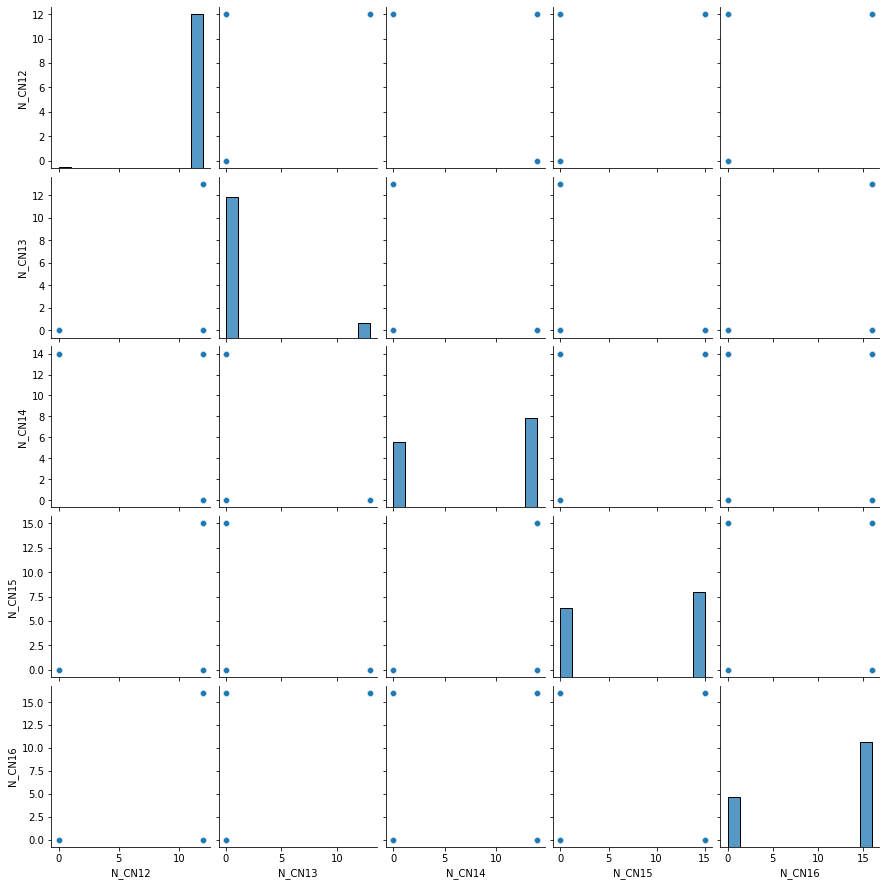

In [58]:
sns.pairplot(CN)

In [ ]:
sns.pairplot(CNPyscal)